# 习题册 CSV 数据分析

使用 `pandas + matplotlib + seaborn` 分析 `数据分析/csv/` 中的习题册 CSV。默认示例文件是 `03_王道计组.csv`。

内容包括：数据清洗、总体指标、章节汇总、薄弱小节、清晰热力图、正确率分布、题量-正确率散点图、多 CSV 横向对比。

In [ ]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

cwd = Path.cwd()
if (cwd / 'csv').exists():
    PROJECT_DIR = cwd
elif (cwd / '数据分析' / 'csv').exists():
    PROJECT_DIR = cwd / '数据分析'
else:
    PROJECT_DIR = Path('.')

CSV_DIR = PROJECT_DIR / 'csv'
FIG_DIR = PROJECT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

DATA_FILE = CSV_DIR / '03_王道计组.csv' // '03_王道计组成绩.csv'

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'Arial Unicode MS']
chosen_font = next((font for font in preferred_fonts if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.sans-serif'] = [chosen_font]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', font=chosen_font, rc={'axes.unicode_minus': False})

print(f'项目目录: {PROJECT_DIR.resolve()}')
print(f'默认数据文件: {DATA_FILE.resolve()}')
print(f'绘图字体: {chosen_font}')

项目目录: C:\Users\34406\Documents\Obsidian Vault\数据分析
默认数据文件: C:\Users\34406\Documents\Obsidian Vault\数据分析\csv\03_王道计组.csv
绘图字体: Microsoft YaHei


## 1. 数据读取与清洗

CSV 来自 Excel 的单个工作表。此函数会自动识别章节行、小节行、一刷/二刷题量、正确数和正确率。没有题量的数据行会被跳过。

In [2]:
def _num(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace(',', '').replace('，', '')
    if text == '':
        return np.nan
    if text.endswith(('%', '％')):
        number = pd.to_numeric(text[:-1].strip(), errors='coerce')
        return number / 100 if pd.notna(number) else np.nan
    return pd.to_numeric(text, errors='coerce')

def _rate(correct, total, fallback=np.nan):
    if pd.notna(total) and total > 0:
        return correct / total
    return fallback if pd.notna(fallback) else np.nan

def read_raw_csv(path):
    raw = pd.read_csv(path, header=None, dtype=str, encoding='utf-8-sig').fillna('')
    raw = raw.reindex(columns=range(max(9, raw.shape[1])), fill_value='')
    return raw

def parse_exercise_csv(path):
    path = Path(path)
    raw = read_raw_csv(path)
    title_candidates = raw.iloc[:, 0].astype(str).str.strip()
    title = title_candidates[title_candidates.ne('')].iloc[0] if title_candidates.ne('').any() else path.stem

    header_mask = raw.iloc[:, 0].astype(str).str.strip().isin(['小节', '章节'])
    header_idx = int(header_mask[header_mask].index[0]) if header_mask.any() else 3

    records = []
    current_chapter = '未分章'
    current_chapter_no = np.nan
    skipped_no_total = 0

    for _, row in raw.iloc[header_idx + 1:].iterrows():
        label = str(row[0]).strip()
        if not label:
            continue

        chapter_match = re.match(r'^第(\d+)章', label)
        if chapter_match:
            current_chapter = label
            current_chapter_no = int(chapter_match.group(1))
            continue

        if label.replace(' ', '') in {'合计', '总计'} or label.startswith('【'):
            continue

        first_total = _num(row[2])
        first_correct = _num(row[3])
        first_rate_raw = _num(row[4])
        second_total = _num(row[6])
        second_correct = _num(row[7])
        second_rate_raw = _num(row[8])

        if pd.isna(first_total) and pd.isna(first_correct) and pd.isna(first_rate_raw) and pd.isna(second_total) and pd.isna(second_correct):
            skipped_no_total += 1
            continue

        first_total = 0 if pd.isna(first_total) else int(first_total)
        first_correct = 0 if pd.isna(first_correct) else int(first_correct)
        second_total = 0 if pd.isna(second_total) else int(second_total)
        second_correct = 0 if pd.isna(second_correct) else int(second_correct)
        first_rate = _rate(first_correct, first_total, first_rate_raw)
        second_rate = _rate(second_correct, second_total, second_rate_raw)

        section_match = re.match(r'^(\d+(?:\.\d+)+)', label)
        records.append({
            'source_file': path.name,
            'title': title,
            'chapter': current_chapter,
            'chapter_no': current_chapter_no,
            'section': label,
            'section_no': section_match.group(1) if section_match else '',
            'date_or_page': str(row[1]).strip(),
            'first_total': first_total,
            'first_correct': first_correct,
            'first_wrong': max(first_total - first_correct, 0),
            'first_rate': first_rate,
            'second_total': second_total,
            'second_correct': second_correct,
            'second_wrong': max(second_total - second_correct, 0),
            'second_rate': second_rate,
        })

    df = pd.DataFrame(records)
    if not df.empty:
        df['chapter_no'] = pd.to_numeric(df['chapter_no'], errors='coerce')
        df['section_order'] = df.groupby('chapter').cumcount() + 1
        df['first_rate_pct'] = df['first_rate'] * 100
        df['second_rate_pct'] = df['second_rate'] * 100

    meta = {'path': path, 'title': title, 'header_idx': header_idx, 'skipped_no_total': skipped_no_total}
    return raw, df, meta

raw, df, meta = parse_exercise_csv(DATA_FILE)

display(Markdown(f"**文件：** `{meta['path']}`  \\n**标题：** {meta['title']}  \\n**有效小节：** {len(df)}  \\n**跳过无题量行：** {meta['skipped_no_total']}"))
display(df.head(10))

**文件：** `c:\Users\34406\Documents\Obsidian Vault\数据分析\csv\03_王道计组.csv`  \n**标题：** 王道计算机组成原理 课后习题正确率记录  \n**有效小节：** 27  \n**跳过无题量行：** 1

,source_file,title,chapter,chapter_no,section,section_no,date_or_page,first_total,first_correct,first_wrong,first_rate,second_total,second_correct,second_wrong,second_rate,section_order,first_rate_pct,second_rate_pct
0,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第1章 计算机系统概述,1,1.1 计算机发展历程,1.1,507,1,1,0,1.000000,0,0,0,NaN,1,100.000000,NaN
1,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第1章 计算机系统概述,1,1.2 计算机系统层次结构,1.2,507,14,13,1,0.928571,0,0,0,NaN,2,92.857143,NaN
2,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第1章 计算机系统概述,1,1.3 计算机的性能指标,1.3,508,20,12,8,0.600000,0,0,0,NaN,3,60.000000,NaN
3,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第2章 数据的表示和运算,2,2.1 数制与编码,2.1,509,34,25,9,0.735294,0,0,0,NaN,1,73.529412,NaN
4,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第2章 数据的表示和运算,2,2.2 运算方法和运算电路,2.2,510,35,25,10,0.714286,0,0,0,NaN,2,71.428571,NaN
5,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第2章 数据的表示和运算,2,2.3 浮点数的表示与运算,2.3,512,45,37,8,0.822222,0,0,0,NaN,3,82.222222,NaN
6,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第3章 存储系统,3,3.1 存储器概述,3.1,513,11,10,1,0.909091,0,0,0,NaN,1,90.909091,NaN
7,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第3章 存储系统,3,3.2 主存储器,3.2,514,37,30,7,0.810811,0,0,0,NaN,2,81.081081,NaN
8,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第3章 存储系统,3,3.3 主存储器与CPU的连接,3.3,515,15,11,4,0.733333,0,0,0,NaN,3,73.333333,NaN
9,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,第3章 存储系统,3,3.4 外部存储器,3.4,516,12,9,3,0.750000,0,0,0,NaN,4,75.000000,NaN


## 2. 总体指标与薄弱小节

先看总览，再列出最需要复盘的小节。

In [3]:
def make_summary(df):
    first_total = df['first_total'].sum()
    first_correct = df['first_correct'].sum()
    second_total = df['second_total'].sum()
    second_correct = df['second_correct'].sum()
    return pd.DataFrame([
        {'指标': '有效小节数', '值': len(df)},
        {'指标': '一刷总题', '值': first_total},
        {'指标': '一刷正确', '值': first_correct},
        {'指标': '一刷错误', '值': first_total - first_correct},
        {'指标': '一刷总体正确率', '值': first_correct / first_total if first_total else np.nan},
        {'指标': '一刷小节平均正确率', '值': df['first_rate'].mean()},
        {'指标': '二刷总题', '值': second_total},
        {'指标': '二刷正确', '值': second_correct},
        {'指标': '二刷总体正确率', '值': second_correct / second_total if second_total else np.nan},
    ])

summary_df = make_summary(df)
display(summary_df.style.format({'值': lambda x: f'{x:.2%}' if isinstance(x, float) and 0 <= x <= 1 else ('' if pd.isna(x) else f'{x:g}')}))

weak_df = df[df['first_total'] > 0].sort_values(['first_rate', 'first_total'], ascending=[True, False]).head(10)
display(
    weak_df[['chapter', 'section', 'first_total', 'first_correct', 'first_wrong', 'first_rate']]
    .style.format({'first_rate': '{:.1%}'})
    .background_gradient(cmap='RdYlGn', subset=['first_rate'], vmin=0, vmax=1)
)


,指标,值
0,有效小节数,27
1,一刷总题,593
2,一刷正确,438
3,一刷错误,155
4,一刷总体正确率,73.86%
5,一刷小节平均正确率,76.57%
6,二刷总题,0.00%
7,二刷正确,0.00%
8,二刷总体正确率,


,chapter,section,first_total,first_correct,first_wrong,first_rate
19,第5章 中央处理器,5.5 异常和中断机制,13,7,6,53.8%
25,第7章 输入/输出系统,7.2 I/O接口,17,10,7,58.8%
26,第7章 输入/输出系统,7.3 I/O方式,55,33,22,60.0%
2,第1章 计算机系统概述,1.3 计算机的性能指标,20,12,8,60.0%
11,第3章 存储系统,3.6 虚拟存储器,20,12,8,60.0%
15,第5章 中央处理器,5.1 CPU的功能和基本结构,24,15,9,62.5%
10,第3章 存储系统,3.5 高速缓冲存储器,35,22,13,62.9%
17,第5章 中央处理器,5.3 数据通路的功能和基本结构,18,12,6,66.7%
4,第2章 数据的表示和运算,2.2 运算方法和运算电路,35,25,10,71.4%
16,第5章 中央处理器,5.2 指令执行过程,11,8,3,72.7%


## 3. 章节汇总

按章节聚合题量、正确数、正确率，并找出每章最低正确率的小节。

In [4]:
chapter_df = (
    df.groupby(['chapter_no', 'chapter'], dropna=False)
    .agg(
        sections=('section', 'count'),
        first_total=('first_total', 'sum'),
        first_correct=('first_correct', 'sum'),
        first_wrong=('first_wrong', 'sum'),
        avg_section_rate=('first_rate', 'mean'),
        second_total=('second_total', 'sum'),
        second_correct=('second_correct', 'sum'),
    )
    .reset_index()
)
chapter_df['first_rate'] = chapter_df['first_correct'] / chapter_df['first_total'].replace(0, np.nan)
chapter_df['second_rate'] = chapter_df['second_correct'] / chapter_df['second_total'].replace(0, np.nan)
chapter_df = chapter_df.sort_values('chapter_no')

weak_by_chapter = (
    df[df['first_total'] > 0]
    .sort_values(['chapter_no', 'first_rate', 'first_total'], ascending=[True, True, False])
    .groupby('chapter', as_index=False)
    .first()[['chapter', 'section', 'first_rate']]
    .rename(columns={'section': 'weakest_section', 'first_rate': 'weakest_rate'})
)
chapter_df = chapter_df.merge(weak_by_chapter, on='chapter', how='left')

display(
    chapter_df[['chapter', 'sections', 'first_total', 'first_correct', 'first_wrong', 'first_rate', 'avg_section_rate', 'weakest_section', 'weakest_rate']]
    .style.format({'first_rate': '{:.1%}', 'avg_section_rate': '{:.1%}', 'weakest_rate': '{:.1%}'})
    .background_gradient(cmap='RdYlGn', subset=['first_rate', 'avg_section_rate', 'weakest_rate'], vmin=0, vmax=1)
)


,chapter,sections,first_total,first_correct,first_wrong,first_rate,avg_section_rate,weakest_section,weakest_rate
0,第1章 计算机系统概述,3,35,26,9,74.3%,84.3%,1.3 计算机的性能指标,60.0%
1,第2章 数据的表示和运算,3,114,87,27,76.3%,75.7%,2.2 运算方法和运算电路,71.4%
2,第3章 存储系统,6,130,94,36,72.3%,73.9%,3.6 虚拟存储器,60.0%
3,第4章 指令系统,3,55,43,12,78.2%,83.6%,4.1 指令系统,75.0%
4,第5章 中央处理器,7,138,105,33,76.1%,73.5%,5.5 异常和中断机制,53.8%
5,第6章 总线,2,45,36,9,80.0%,80.0%,6.1 总线概述,80.0%
6,第7章 输入/输出系统,3,76,47,29,61.8%,72.9%,7.2 I/O接口,58.8%


## 4. 清晰热力图

每个格子是一个小节，颜色是一刷正确率。图像尺寸会根据章节数和每章小节数自动放大；格子中直接标注“小节号 + 正确率”。

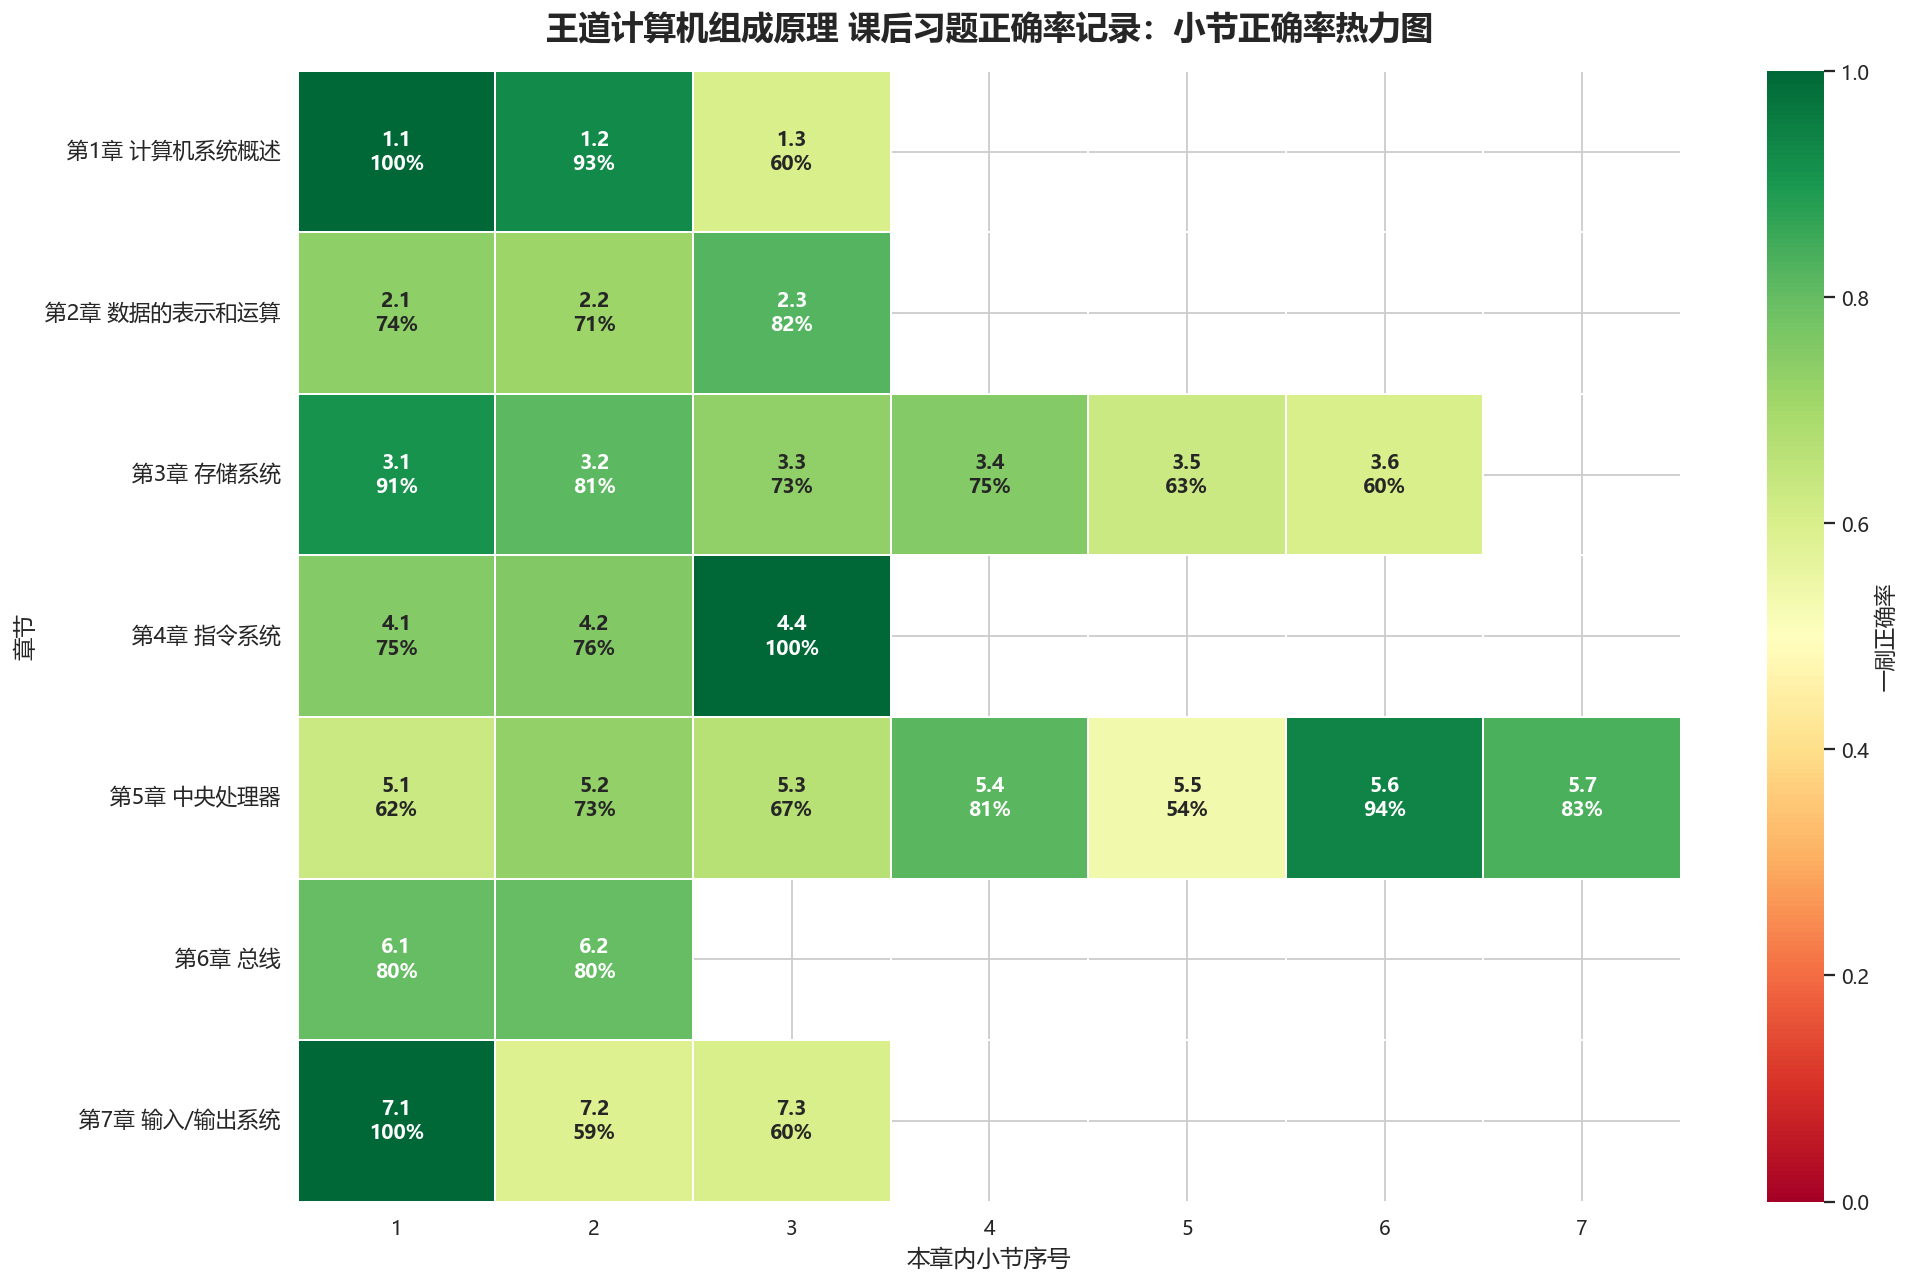

In [5]:
heat_df = df[df['first_total'] > 0].copy()
heat_matrix = heat_df.pivot_table(index='chapter', columns='section_order', values='first_rate', aggfunc='mean')
annot_matrix = heat_df.pivot_table(
    index='chapter',
    columns='section_order',
    values='section_no',
    aggfunc='first',
).reindex_like(heat_matrix).fillna('')

annot = heat_matrix.copy().astype(object)
for r in heat_matrix.index:
    for c in heat_matrix.columns:
        value = heat_matrix.loc[r, c]
        label = annot_matrix.loc[r, c]
        annot.loc[r, c] = '' if pd.isna(value) else f'{label}\n{value:.0%}'

fig_w = max(14, 1.55 * heat_matrix.shape[1] + 5)
fig_h = max(7, 1.15 * heat_matrix.shape[0] + 2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    heat_matrix,
    annot=annot,
    fmt='',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=1.0,
    linecolor='white',
    cbar_kws={'label': '一刷正确率'},
    annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    ax=ax,
)
ax.set_title(f'{meta["title"]}：小节正确率热力图', fontsize=18, fontweight='bold', pad=18)
ax.set_xlabel('本章内小节序号', fontsize=13)
ax.set_ylabel('章节', fontsize=13)
ax.tick_params(axis='x', labelrotation=0, labelsize=11)
ax.tick_params(axis='y', labelrotation=0, labelsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / '03_王道计组_小节正确率热力图.png', dpi=180, bbox_inches='tight')
plt.show()


## 5. 章节正确率、题量与分布

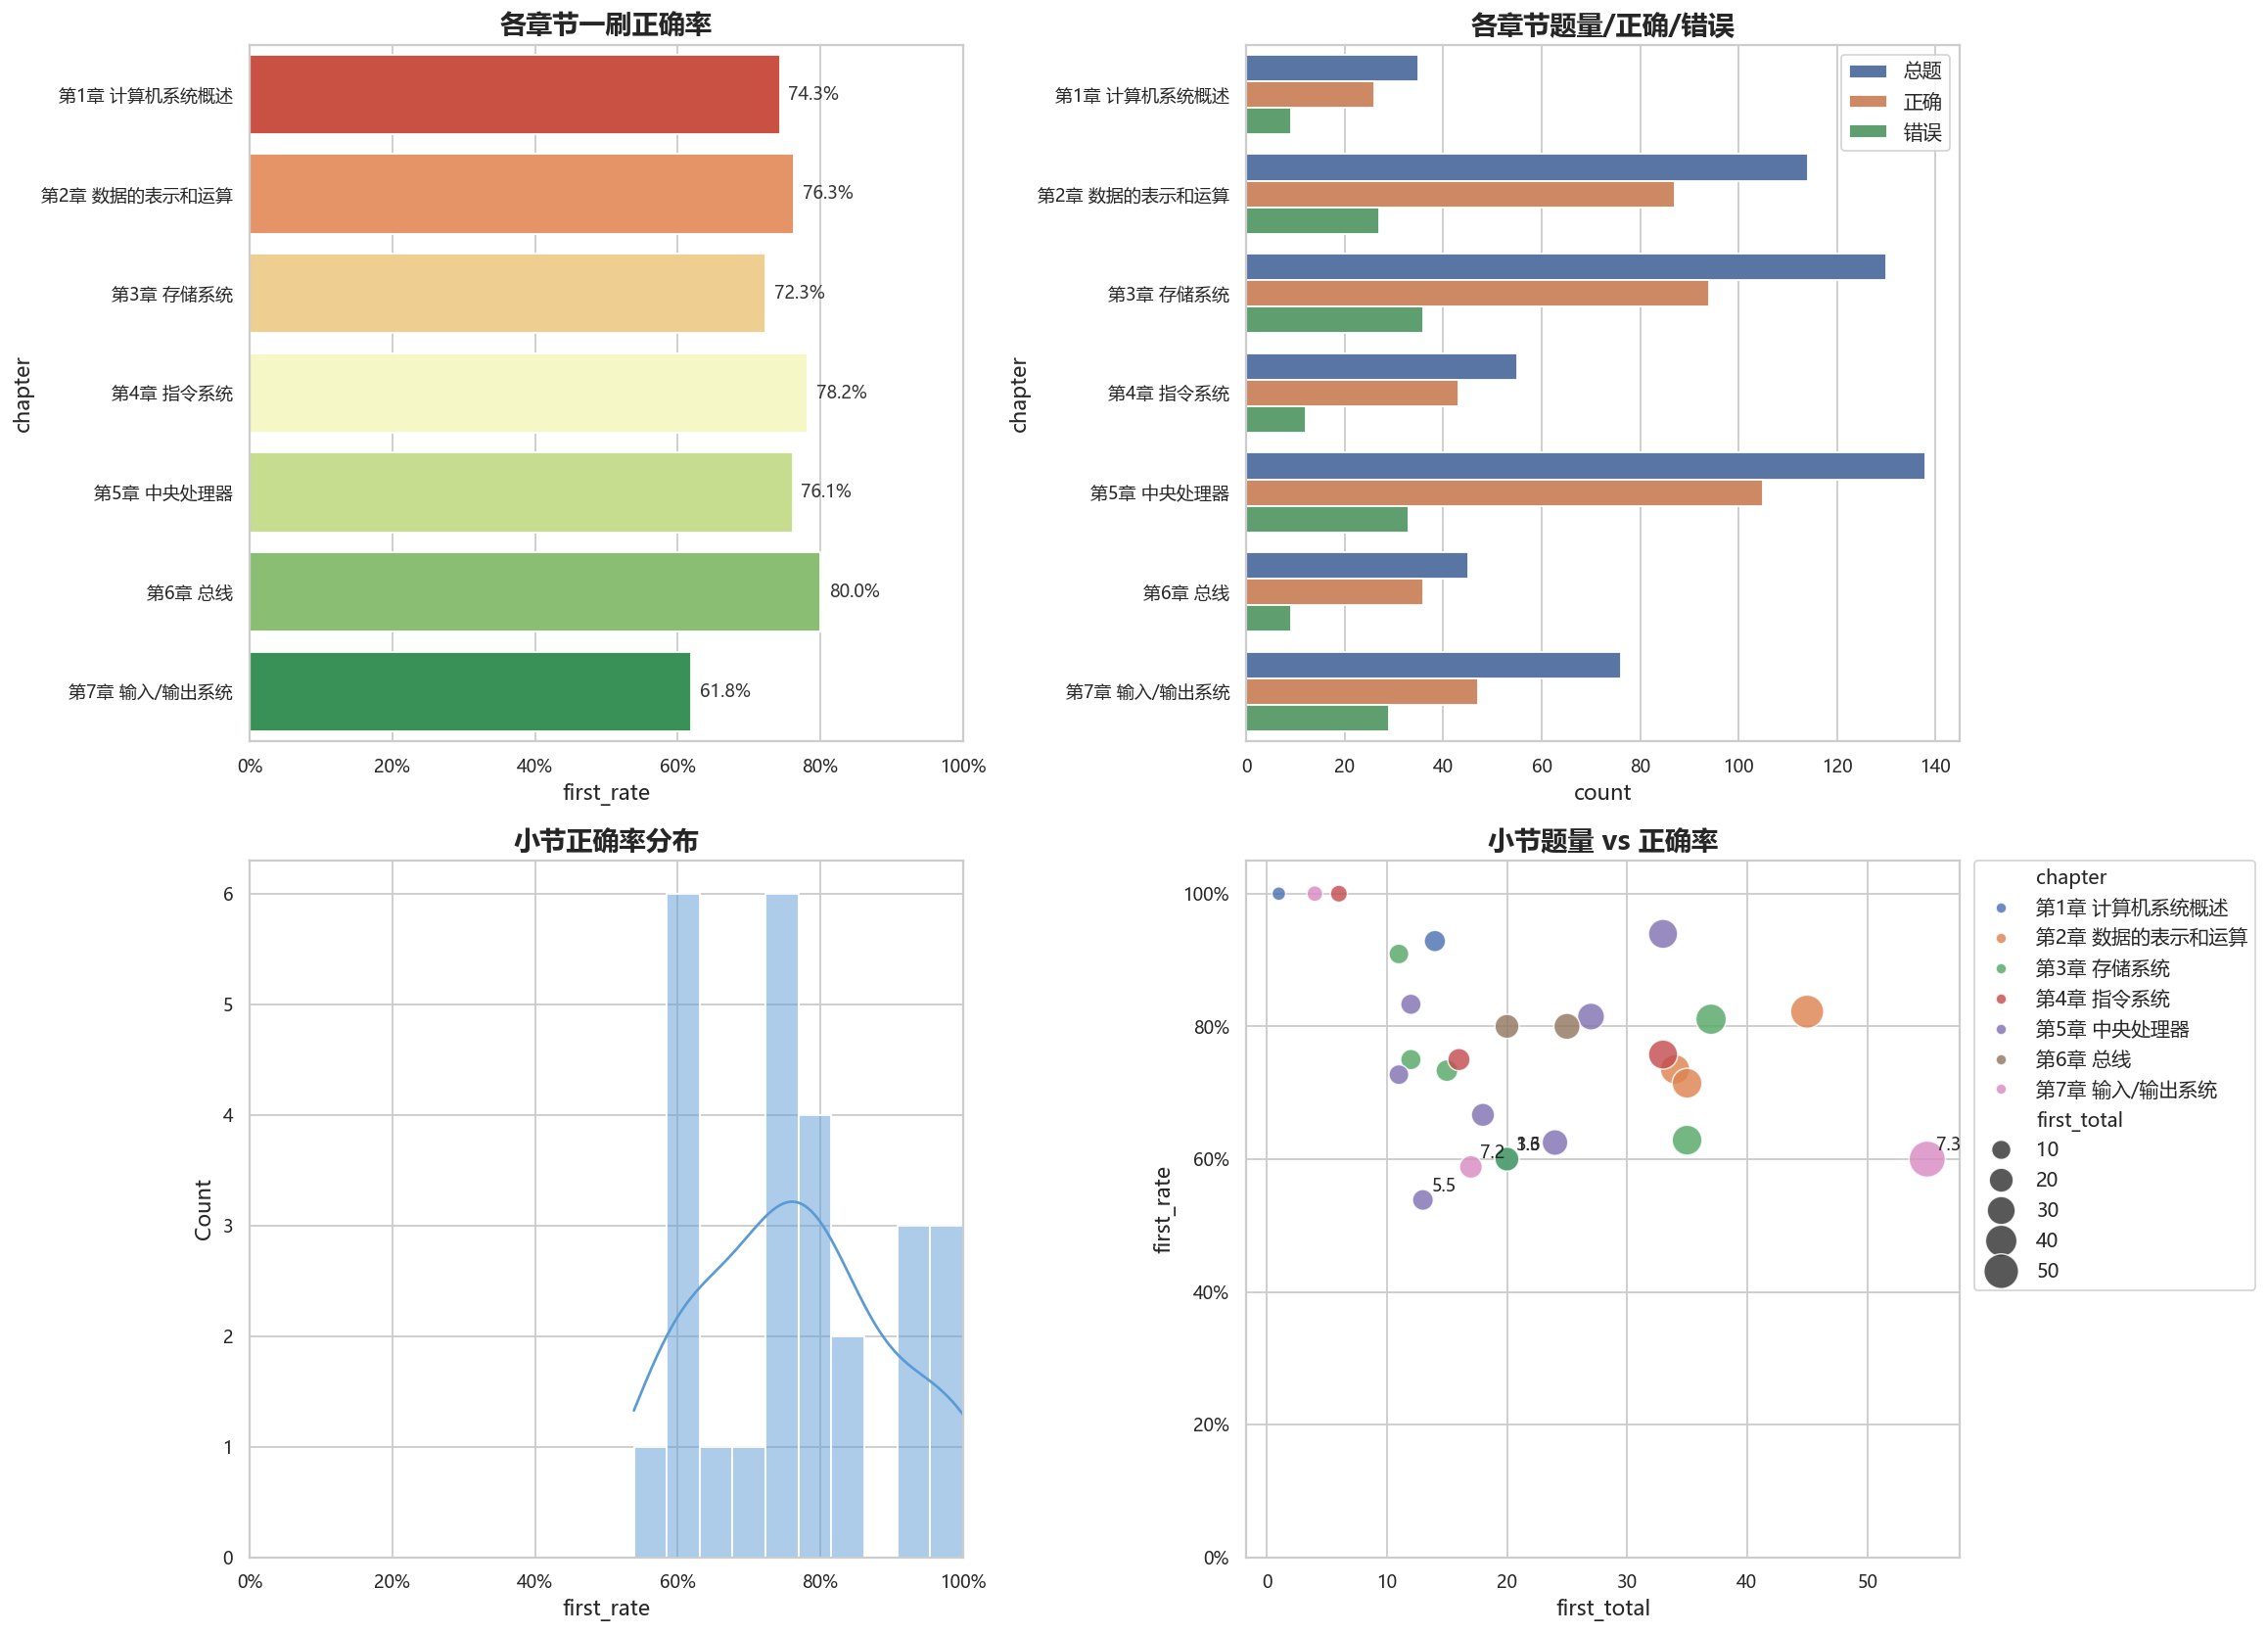

In [6]:
def annotate_rate_axis(ax, values, x_offset=0.012):
    for patch, value in zip(ax.patches, values):
        if pd.isna(value):
            continue
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(min(width + x_offset, 0.985), y, f'{value:.1%}', va='center', ha='left', fontsize=10, color='#333')

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

sns.barplot(data=chapter_df, y='chapter', x='first_rate', hue='chapter', palette='RdYlGn', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('各章节一刷正确率', fontsize=15, fontweight='bold')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
annotate_rate_axis(axes[0, 0], chapter_df['first_rate'].tolist())

chapter_long = chapter_df.melt(id_vars='chapter', value_vars=['first_total', 'first_correct', 'first_wrong'], var_name='metric', value_name='count')
metric_names = {'first_total': '总题', 'first_correct': '正确', 'first_wrong': '错误'}
chapter_long['metric'] = chapter_long['metric'].map(metric_names)
sns.barplot(data=chapter_long, y='chapter', x='count', hue='metric', ax=axes[0, 1])
axes[0, 1].set_title('各章节题量/正确/错误', fontsize=15, fontweight='bold')
axes[0, 1].legend(title='')

sns.histplot(data=df[df['first_total'] > 0], x='first_rate', bins=10, kde=True, color='#5B9BD5', ax=axes[1, 0])
axes[1, 0].set_title('小节正确率分布', fontsize=15, fontweight='bold')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

scatter_df = df[df['first_total'] > 0].copy()
sns.scatterplot(data=scatter_df, x='first_total', y='first_rate', size='first_total', hue='chapter', sizes=(60, 420), alpha=0.82, ax=axes[1, 1])
axes[1, 1].set_title('小节题量 vs 正确率', fontsize=15, fontweight='bold')
axes[1, 1].yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
axes[1, 1].set_ylim(0, 1.05)
for _, row in scatter_df.nsmallest(5, 'first_rate').iterrows():
    axes[1, 1].annotate(row['section_no'], (row['first_total'], row['first_rate']), xytext=(5, 5), textcoords='offset points', fontsize=10)
axes[1, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

for ax in axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)
    ax.tick_params(labelsize=10)

plt.tight_layout()
fig.savefig(FIG_DIR / '03_王道计组_章节与分布分析.png', dpi=180, bbox_inches='tight')
plt.show()


## 6. 多 CSV 横向对比

扫描 `csv/` 下所有明细表，比较各资料的一刷正确率、题量、错题量。

,file,title,sections,first_total,first_correct,first_wrong,first_rate,avg_section_rate
0,01_张宇1000题.csv,张宇1000题 习题册正确率记录,5,542,434,108,80.1%,86.5%
1,02_王道操作系统.csv,王道操作系统 课后习题正确率记录,10,361,274,87,75.9%,74.7%
2,03_王道计组.csv,王道计算机组成原理 课后习题正确率记录,27,593,438,155,73.9%,76.6%


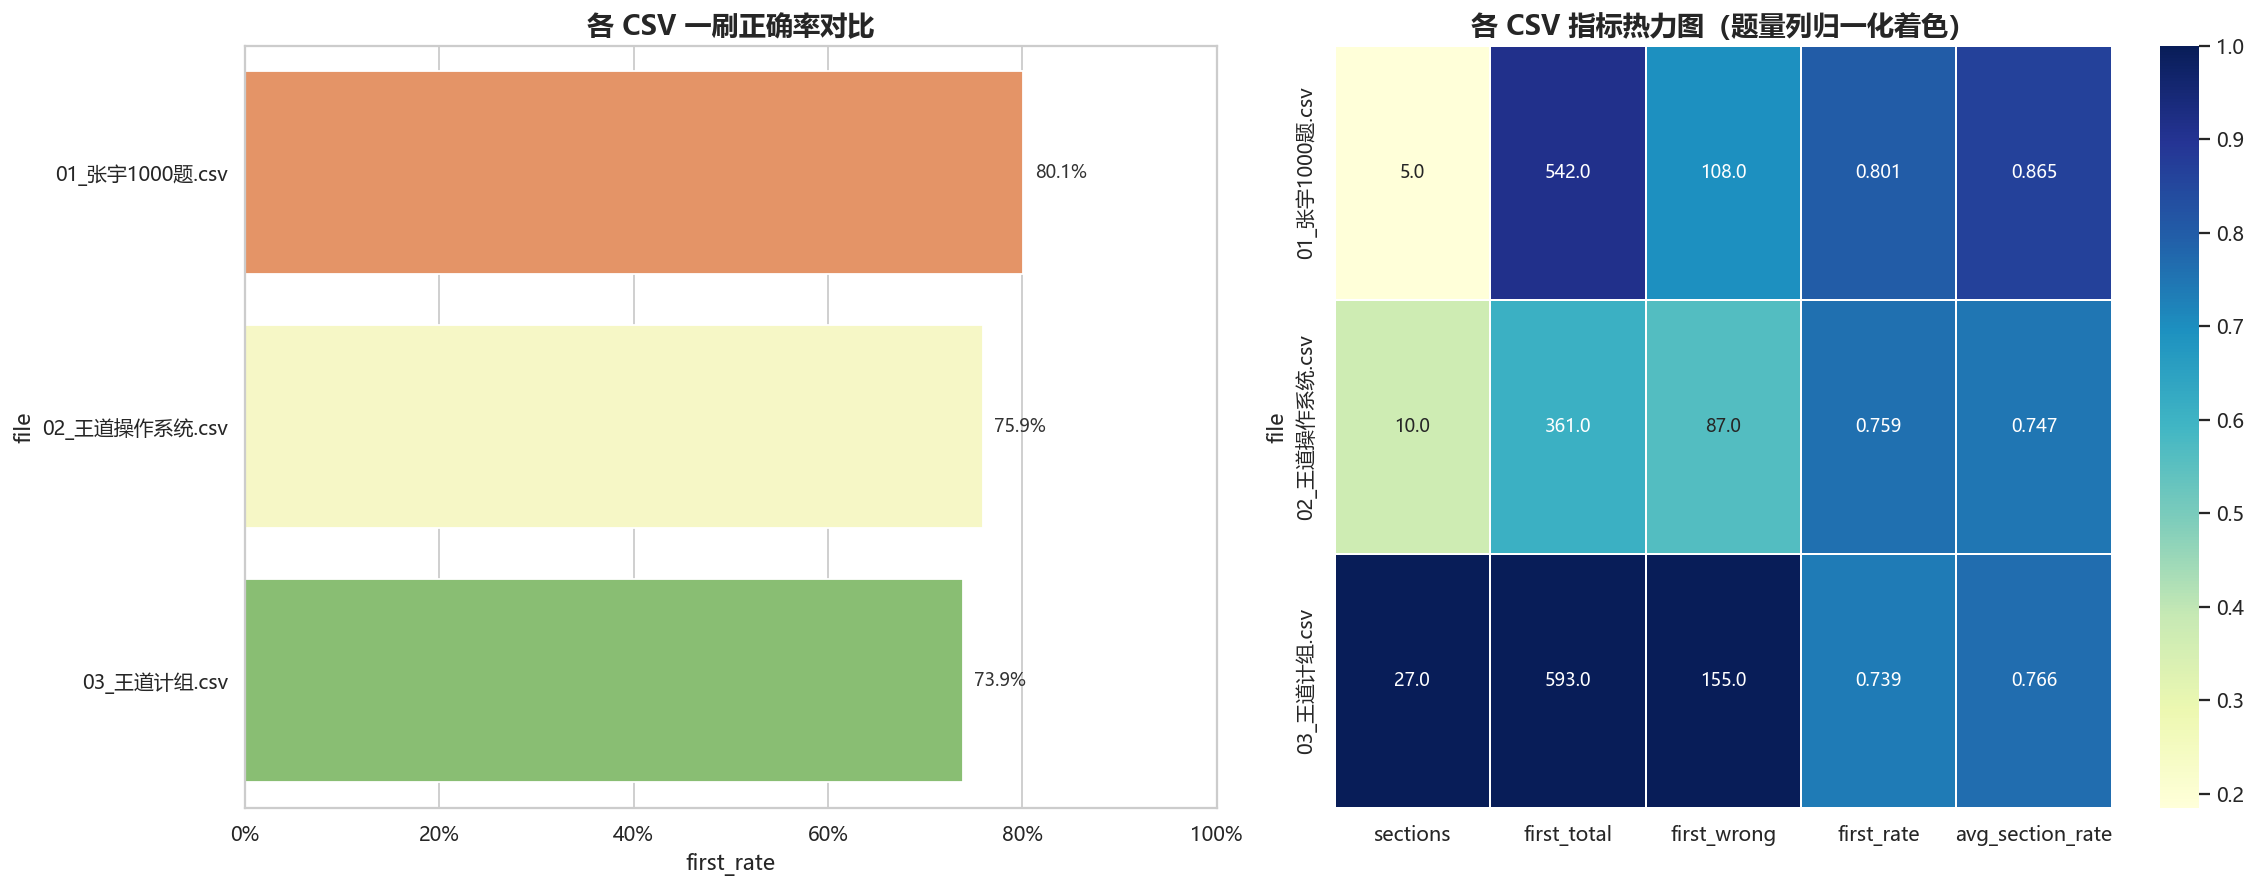

In [7]:
all_summaries = []
all_records = []
for path in sorted(CSV_DIR.glob('*.csv')):
    if path.name == 'manifest.csv':
        continue
    _, one_df, one_meta = parse_exercise_csv(path)
    if one_df.empty:
        continue
    total = one_df['first_total'].sum()
    correct = one_df['first_correct'].sum()
    one_df = one_df.assign(file=path.name)
    all_records.append(one_df)
    all_summaries.append({
        'file': path.name,
        'title': one_meta['title'],
        'sections': len(one_df),
        'first_total': total,
        'first_correct': correct,
        'first_wrong': total - correct,
        'first_rate': correct / total if total else np.nan,
        'avg_section_rate': one_df['first_rate'].mean(),
    })

compare_df = pd.DataFrame(all_summaries).sort_values('file')
display(compare_df.style.format({'first_rate': '{:.1%}', 'avg_section_rate': '{:.1%}'}).background_gradient(cmap='RdYlGn', subset=['first_rate', 'avg_section_rate'], vmin=0, vmax=1))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.barplot(data=compare_df, y='file', x='first_rate', hue='file', palette='RdYlGn', legend=False, ax=axes[0])
axes[0].set_title('各 CSV 一刷正确率对比', fontsize=15, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
annotate_rate_axis(axes[0], compare_df['first_rate'].tolist())

heat_metrics = compare_df.set_index('file')[['sections', 'first_total', 'first_wrong', 'first_rate', 'avg_section_rate']]
heat_norm = heat_metrics.copy()
for col in ['sections', 'first_total', 'first_wrong']:
    max_val = heat_norm[col].max()
    heat_norm[col] = heat_norm[col] / max_val if max_val else 0
sns.heatmap(heat_norm, annot=heat_metrics.round(3), fmt='', cmap='YlGnBu', linewidths=1, linecolor='white', ax=axes[1], annot_kws={'fontsize': 10})
axes[1].set_title('各 CSV 指标热力图（题量列归一化着色）', fontsize=15, fontweight='bold')

plt.tight_layout()
fig.savefig(FIG_DIR / '全部CSV_横向对比.png', dpi=180, bbox_inches='tight')
plt.show()


## 7. 批量扫描并导出

扫描 `csv/` 下全部 CSV，为每张表导出一个对应文件夹，并在 `_汇总/` 下生成横向对比。

In [8]:
import sys
from pathlib import Path

SCRIPT_DIR = PROJECT_DIR / 'scripts'
if str(SCRIPT_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR.resolve()))

from analyze_csv_folder import analyze_csv_folder, scan_csv_files

OUT_DIR = PROJECT_DIR / '分析结果'
csv_files = scan_csv_files(CSV_DIR)
print(f'发现 {len(csv_files)} 个 CSV：')
for csv_path in csv_files:
    print(f'- {csv_path.name}')

batch_summary = analyze_csv_folder(CSV_DIR, OUT_DIR, clean_existing=True)
display(
    batch_summary[['source_file', 'sections_with_first_data', 'first_total', 'first_correct', 'first_wrong', 'first_rate', 'folder']]
    .style.format({'first_rate': '{:.1%}'})
    .background_gradient(cmap='RdYlGn', subset=['first_rate'], vmin=0, vmax=1)
)
print(f'批量分析结果目录: {OUT_DIR.resolve()}')


发现 5 个 CSV：
- 01_张宇1000题.csv
- 02_王道操作系统.csv
- 03_王道计组.csv
- 04_王道数据结构.csv
- 05_王道计网.csv
已分析：01_张宇1000题.csv -> c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\01_张宇1000题
已分析：02_王道操作系统.csv -> c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\02_王道操作系统
已分析：03_王道计组.csv -> c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\03_王道计组
已分析：04_王道数据结构.csv -> c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\04_王道数据结构
已分析：05_王道计网.csv -> c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\05_王道计网


,source_file,sections_with_first_data,first_total,first_correct,first_wrong,first_rate,folder
0,01_张宇1000题.csv,3,542,434,108,80.1%,c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\01_张宇1000题
1,02_王道操作系统.csv,10,361,274,87,75.9%,c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\02_王道操作系统
2,03_王道计组.csv,27,593,438,155,73.9%,c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\03_王道计组
3,04_王道数据结构.csv,0,0,0,0,nan%,c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\04_王道数据结构
4,05_王道计网.csv,0,0,0,0,nan%,c:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果\05_王道计网


批量分析结果目录: C:\Users\34406\Documents\Obsidian Vault\数据分析\分析结果


## 8. 后续分析方向

- 如果开始记录二刷数据，可以新增“一刷 vs 二刷提升幅度”热力图。
- 如果有套卷成绩，可做“套卷 × 题型/章节”的得分率热力图，这是成绩分析里最有价值的一类图。
- 如果加入日期维度，可以画移动平均、近 7 次正确率趋势、错题回炉效率。